In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
# Выводит краткую сводную информацию о структуре таблицы.
df.info


<bound method DataFrame.info of               Дата  Склад   Контрагент Номенклатура  Количество
0       2018-01-04      1    address_0    product_0           4
1       2018-01-04      1    address_0    product_1           4
2       2018-01-04      1    address_0    product_2           5
3       2018-01-04      1    address_0    product_3          10
4       2018-01-04      1    address_0    product_4           2
...            ...    ...          ...          ...         ...
301350  2018-08-31      5  address_173   product_15           0
301351  2018-08-31      5  address_173   product_17           1
301352  2018-08-31      5  address_173   product_18           1
301353  2018-08-31      5  address_173   product_19           0
301354  2018-08-31      5  address_173   product_20           2

[301355 rows x 5 columns]>

Проверяем формат столбцов

In [3]:
# Выводит список всех столбцов и их типы данных
df.dtypes


Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
# 1. Переводим столбец "Дата" в формат datetime
df["Дата"] = pd.to_datetime(df["Дата"], errors="coerce")

# 2. Проверяем результат (в выводе должно быть datetime64[ns])
print(df["Дата"].dtype)

# 3. Смотрим на первые строки, чтобы убедиться в правильности отображения
df[["Дата"]].head()


datetime64[ns]


,Дата
0,2018-01-04
1,2018-01-04
2,2018-01-04
3,2018-01-04
4,2018-01-04


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby("Дата").size().reset_index(name="Количество продаж")


Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()


,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

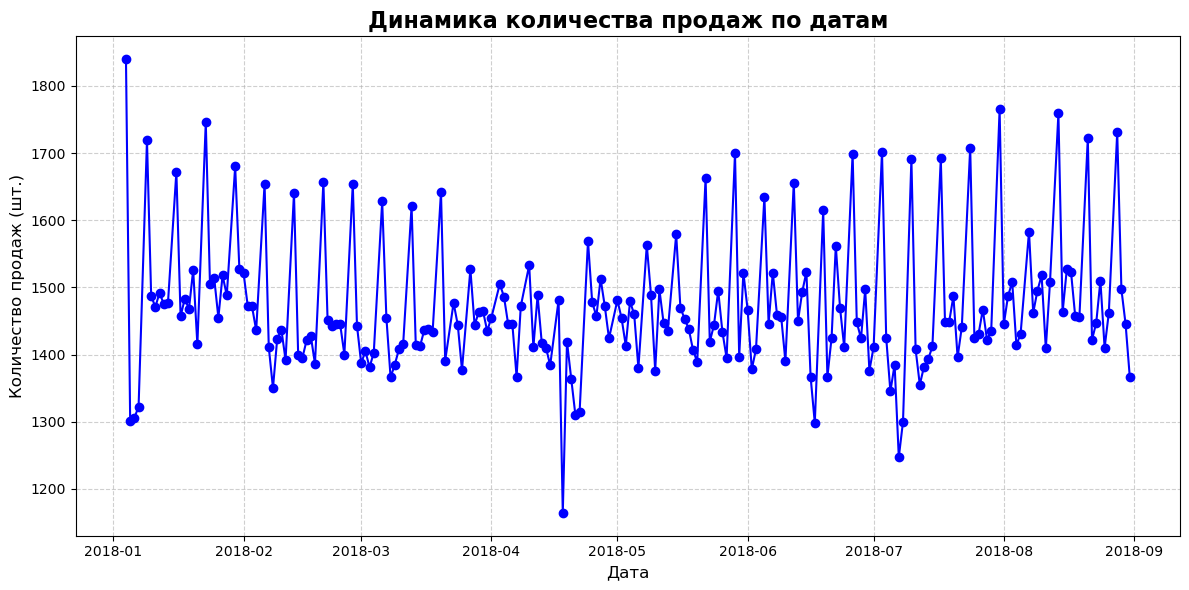

In [10]:
# 1. Настройка размера графика (ширина=12, высота=6 дюймов)
plt.figure(figsize=(12, 6))

# 2. Построение линейного графика
plt.plot(
    grouped_df["Дата"],
    grouped_df["Количество продаж"],
    marker="o",
    color="blue",
    linestyle="-",
)

# 3. Добавление заголовка и подписей к осям
plt.title("Динамика количества продаж по датам", fontsize=16, fontweight="bold")
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество продаж (шт.)", fontsize=12)

# 4. Включение сетки для удобства чтения
plt.grid(True, linestyle="--", alpha=0.6)

# 5. Автоматическое выравнивание элементов и отображение
plt.tight_layout()
plt.show()


Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
#За отчетные 9 месяцев операционная деятельность компании демонстрирует высокую стабильность с боковым трендом. 
Среднесуточный объем продаж устойчиво удерживается в коридоре 1400–1550 единиц. 
Системных признаков падения спроса или долгосрочного органического роста не обнаружено. 
Любые краткосрочные спады или всплески неизменно возвращаются к среднему историческому значению.
Абсолютный максимум (Январь 2018):В начале января зафиксирован рекордный пик объема реализации — ~1840 единиц за сутки. 
Данный всплеск обусловлен синергией новогодней сезонности и стартовых маркетинговых активностей года.
Абсолютный минимум (Апрель 2018):В середине апреля произошло критическое падение продаж до ~1160 единиц. 
Характер падения указывает на внешний технический или инфраструктурный сбой.
Рекомендуется провести аудит логов за этот период (проблемы с эквайрингом, падение сайта или критический дефицит остатков на складе).
Локальные летние пики (Июль — Август):В третьем квартале бизнес демонстрирует регулярное обновление локальных максимумов, 
стабильно пробивая отметку в 1750 единиц.
Синхронизация логистики с циклами: График требует перевода складской и курьерской логистики на гибкий график работы с усилением смен в выявленные 
пиковые дни для удержания Service Level (уровня сервиса).
Управление рисками (Risk Management): Необходимо выявить триггер «апрельского провала» во избежание его повторения в будущих периодах.
Оптимизация запасов (Stock Management): Минимальный безопасный остаток на складах (Safety Stock) должен рассчитываться с учетом способности 
покрывать пиковый спрос третьего квартала (1700–1750 единиц в сутки).

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:

max_sale_row = df.loc[[df["Количество"].idxmax()]]
print("=== СТРОКА С МАКСИМАЛЬНЫМ ЗНАЧЕНИЕМ ПРОДАЖ ===")
max_sale_row[["Дата", "Склад", "Контрагент", "Номенклатура", "Количество"]]


=== СТРОКА С МАКСИМАЛЬНЫМ ЗНАЧЕНИЕМ ПРОДАЖ ===


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [15]:
# 1. Принудительно приводим столбец "Дата" к формату datetime, чтобы работали фильтры по календарю
df["Дата"] = pd.to_datetime(df["Дата"])

# 2. Фильтруем данные по условиям:
# - Склад: строго 3
# - Месяцы: июнь (6), июль (7), август (8)
# - День недели: среда (в pandas индекс среды равен 2, так как понедельник = 0)
filtered_df = df[
    (df["Склад"] == 3)
    & (df["Дата"].dt.month.isin([6, 7, 8]))
    & (df["Дата"].dt.dayofweek == 2)
].copy()

# 3. Группируем отфильтрованные данные по "Номенклатуре" и суммируем "Количество"
product_sales = (
    filtered_df.groupby("Номенклатура")["Количество"]
    .sum()
    .reset_index(name="Всего продано")
)

# 4. Сортируем полученный список по убыванию продаж
product_sales = product_sales.sort_values(by="Всего продано", ascending=False)

# 5. Выводим топовый товар и ТОП-5 для наглядности
if not product_sales.empty:
    top_product = product_sales.iloc[0]
    print("=== ТОПОВЫЙ ТОВАР ===")
    print(f"Номенклатура: {top_product['Номенклатура']}")
    print(
        f"Общее количество продаж за лето по средам: {top_product['Всего продано']} шт.\n"
    )

    print("--- Топ-5 товаров для проверки ---")
    print(product_sales.head(5).to_string(index=False))
else:
    print(
        "Данные по заданным фильтрам не найдены. Убедитесь, что на Складе 3 были продажи по средам летом 2018 года."
    )


=== ТОПОВЫЙ ТОВАР ===
Номенклатура: product_1
Общее количество продаж за лето по средам: 2267 шт.

--- Топ-5 товаров для проверки ---
Номенклатура  Всего продано
   product_1           2267
   product_2           2060
   product_0           1324
   product_3            914
   product_6            650


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

1. Данные о погоде успешно очищены, сгруппированы и сохранены в 'weather.csv'!
2. Таблицы продаж и погоды успешно объединены!


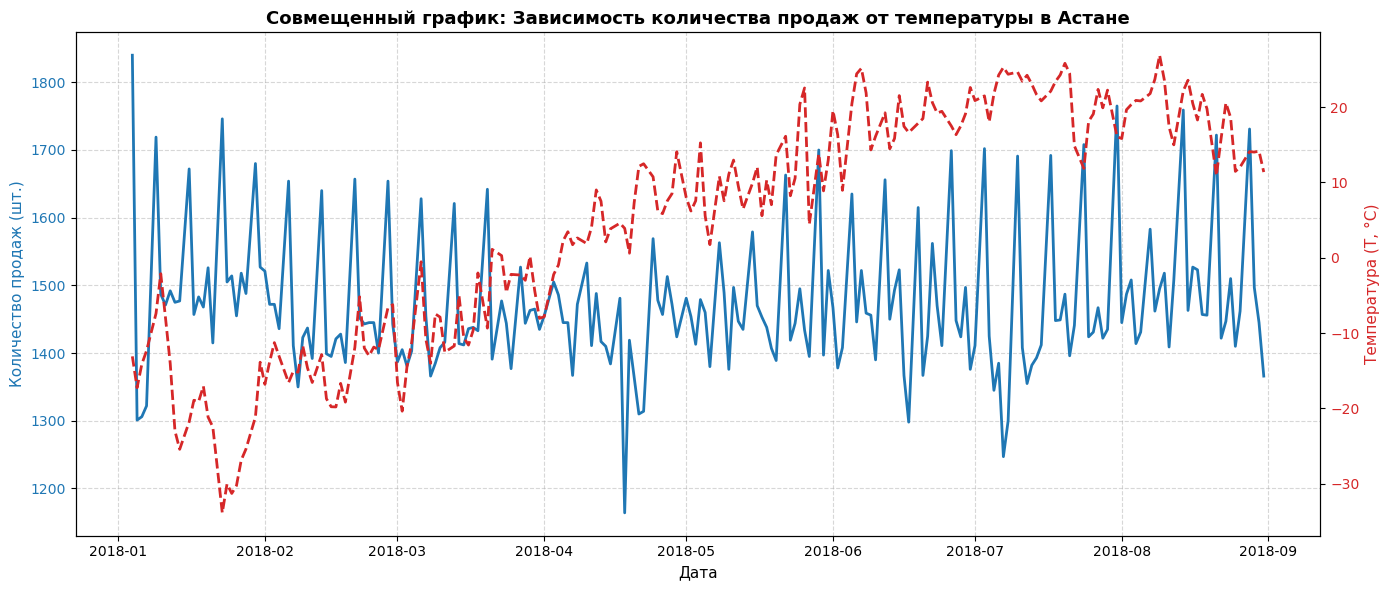

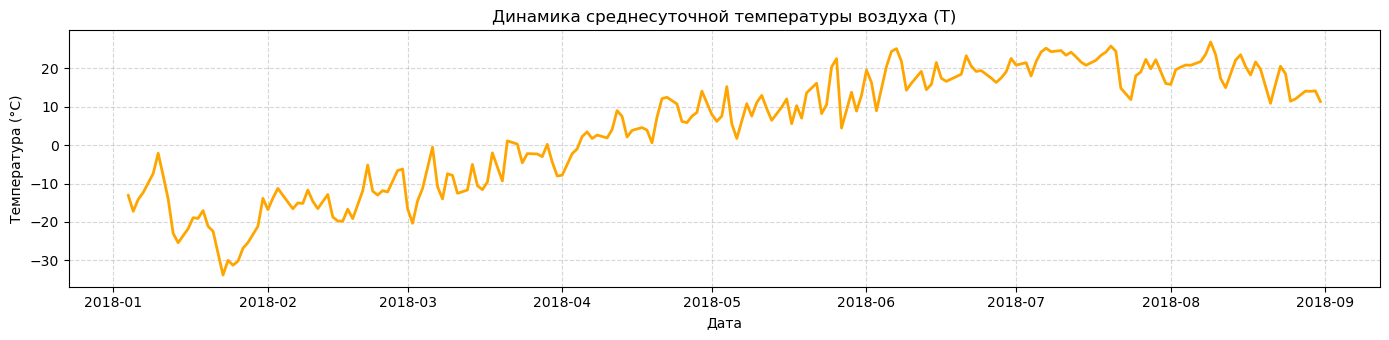

In [22]:


# =========================================================================
# 1. ЧТЕНИЕ И АВТОМАТИЧЕСКАЯ РАЗМЕТКА КОЛОНОК (БЕЗ ШАПКИ)
# =========================================================================
# Читаем файл БЕЗ пропуска строк. Если заголовки сломаны, мы назначим их вручную.
weather_df = pd.read_excel("weather.xlsx")

# Принудительно называем колонки по номерам: 0-я колонка — это время, 1-я — температура
weather_df.rename(
    columns={weather_df.columns[0]: "Дата_Время", weather_df.columns[1]: "T"},
    inplace=True,
)

# Переводим в формат datetime первую колонку (обрабатываем ошибки, если там текст шапки)
weather_df["Дата_Время"] = pd.to_datetime(
    weather_df["Дата_Время"], dayfirst=True, errors="coerce"
)

# Удаляем строки, где дата не смогла распознаться (например, текстовые строки шапки сайта)
weather_df.dropna(subset=["Дата_Время"], inplace=True)

# Выделяем чистую дату (день) для группировки
weather_df["Дата"] = weather_df["Дата_Время"].dt.date
weather_df["Дата"] = pd.to_datetime(weather_df["Дата"])

# Преобразуем температуру во 2-й колонке строго в числа
weather_df["T"] = pd.to_numeric(weather_df["T"], errors="coerce")

# Рассчитываем среднесуточную (среднюю за день) температуру
daily_temp = weather_df.groupby("Дата")["T"].mean().reset_index()

# Сохраняем чистые суточные данные в csv (выполняем ваше условие)
daily_temp.to_csv("weather.csv", index=False, encoding="utf-8-sig")
print("1. Данные о погоде успешно очищены, сгруппированы и сохранены в 'weather.csv'!")


# =========================================================================
# 2. ОБЪЕДИНЕНИЕ С ТАБЛИЦЕЙ ПРОДАЖ (grouped_df)
# =========================================================================
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])

# Объединяем таблицы по общему полю "Дата"
merged_df = pd.merge(grouped_df, daily_temp, on="Дата", how="inner")

# Сортируем по хронологии для корректного построения графиков
merged_df = merged_df.sort_values("Дата").reset_index(drop=True)
print("2. Таблицы продаж и погоды успешно объединены!")


# =========================================================================
# 3. ПОСТРОЕНИЕ СОВМЕЩЕННОГО ГРАФИКА y=['Количество продаж', 'T']
# =========================================================================
fig, ax1 = plt.subplots(figsize=(14, 6))

# Левая ось Y — Количество продаж (синяя линия)
color_sales = "tab:blue"
ax1.set_xlabel("Дата", fontsize=11)
ax1.set_ylabel("Количество продаж (шт.)", color=color_sales, fontsize=11)
ax1.plot(
    merged_df["Дата"],
    merged_df["Количество продаж"],
    color=color_sales,
    linewidth=2,
    label="Количество продаж",
)
ax1.tick_params(axis="y", labelcolor=color_sales)
ax1.grid(True, linestyle="--", alpha=0.5)

# Создаем правую ось Y для температуры T (красная пунктирная линия)
ax2 = ax1.twinx()
color_temp = "tab:red"
ax2.set_ylabel("Температура (T, °C)", color=color_temp, fontsize=11)
ax2.plot(
    merged_df["Дата"],
    merged_df["T"],
    color=color_temp,
    linewidth=2,
    linestyle="--",
    label="Температура T",
)
ax2.tick_params(axis="y", labelcolor=color_temp)

plt.title(
    "Совмещенный график: Зависимость количества продаж от температуры в Астане",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
plt.show()


# =========================================================================
# 4. ПОСТРОЕНИЕ ОТДЕЛЬНОГО ГРАФИКА ТЕМПЕРАТУРЫ
# =========================================================================
plt.figure(figsize=(14, 3.5))
plt.plot(
    merged_df["Дата"],
    merged_df["T"],
    color="orange",
    linewidth=2,
    label="Температура (T)",
)
plt.title("Динамика среднесуточной температуры воздуха (T)", fontsize=12)
plt.xlabel("Дата")
plt.ylabel("Температура (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
